In [1]:
import pandas as pd
import numpy as np

# NLP / Text processing
import re
import string

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("card_transactions.csv")

df.head()

,ID,Transaction Time,Transaction Type,Channel,Is 3DS,Is Token,Decision,Decline Reason Code,Issuer Name,Issuer Country,...,Funding source,Acquirer Name,Acquirer Country,Acquirer Region,Jurisdiction,Is Dispute,Is Fraud,Dispute Type,Amount,Industry Segment
0,T89784025544295,2024-02-20T11:02:49.000Z,Chip,CP,No,No,Approved,Approved,BPCE,FRANCE,...,Credit,BOURSORAMA BANQUE,FRANCE,EUROPE,Domestic,0,0,No Dispute,196.975798,Government services
1,T94028747687247,2024-02-18T10:42:19.000Z,Other CNP,CNP,No,No,Approved,Approved,"BANK OF AMERICA, NATIONAL ASSOCIATION",UNITED STATES OF AMERICA,...,Credit,NAVY FEDERAL CREDIT UNION,UNITED STATES OF AMERICA,USA,Domstic,0,0,No Dispute,340.852463,Contracted services
2,T84800389951860,2024-04-30T11:10:17.000Z,ECI-7,CNP,No,No,Approved,Approved,HSBC UK BANK PLC,UNITED KINGDOM,...,Credit,BARCLAYS BANK UK PLC,UNITED KINGDOM,EUROPE,Domestic,0,0,No Dispute,192.134049,Clothing stores
3,T88418230200974,2024-01-08T19:01:35.000Z,Contactless,CP,No,Yes,Approved,Approved,JPMORGAN CHASE BANK N.A,UNITED STATES OF AMERICA,...,Credit,CHAINA MERCHANTS BANK,CHAINA MAINLAND,APAC,Cross Border,0,0,No Dispute,100.581589,Contracted services
4,T19060182064275,2024-05-14T21:03:51.000Z,Chip,CP,No,No,Approved,Approved,BANCO BRADESCO S.A.,BRAZIL,...,Credit,SUTTON BANK,UNITED STATES OF AMERICA,USA,Cross Border,0,0,No Dispute,424.332753,Utility services


In [3]:
print(df.shape)
print(df.columns)
print(df.info())

(10000, 21)
Index(['ID', 'Transaction Time', 'Transaction Type', 'Channel', 'Is 3DS',
       'Is Token', 'Decision', 'Decline Reason Code', 'Issuer Name',
       'Issuer Country', 'Issuer Region', 'Funding source', 'Acquirer Name',
       'Acquirer Country', 'Acquirer Region', 'Jurisdiction', 'Is Dispute',
       'Is Fraud', 'Dispute Type', 'Amount', 'Industry Segment'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   10000 non-null  str    
 1   Transaction Time     10000 non-null  str    
 2   Transaction Type     10000 non-null  str    
 3   Channel              10000 non-null  str    
 4   Is 3DS               10000 non-null  str    
 5   Is Token             10000 non-null  str    
 6   Decision             10000 non-null  str    
 7   Decline Reason Code  10000 non-null  str    
 8   Issue

In [5]:
df.columns = df.columns.str.strip().str.lower()

print(df.columns)

Index(['id', 'transaction time', 'transaction type', 'channel', 'is 3ds',
       'is token', 'decision', 'decline reason code', 'issuer name',
       'issuer country', 'issuer region', 'funding source', 'acquirer name',
       'acquirer country', 'acquirer region', 'jurisdiction', 'is dispute',
       'is fraud', 'dispute type', 'amount', 'industry segment'],
      dtype='str')


In [7]:
print(df.columns)

Index(['id', 'transaction time', 'transaction type', 'channel', 'is 3ds',
       'is token', 'decision', 'decline reason code', 'issuer name',
       'issuer country', 'issuer region', 'funding source', 'acquirer name',
       'acquirer country', 'acquirer region', 'jurisdiction', 'is dispute',
       'is fraud', 'dispute type', 'amount', 'industry segment'],
      dtype='str')


In [9]:
print(df.head())
print(df.columns.tolist())

                id          transaction time transaction type channel is 3ds  \
0  T89784025544295  2024-02-20T11:02:49.000Z             Chip      CP     No   
1  T94028747687247  2024-02-18T10:42:19.000Z        Other CNP     CNP     No   
2  T84800389951860  2024-04-30T11:10:17.000Z            ECI-7     CNP     No   
3  T88418230200974  2024-01-08T19:01:35.000Z      Contactless      CP     No   
4  T19060182064275  2024-05-14T21:03:51.000Z             Chip      CP     No   

  is token  decision decline reason code  \
0       No  Approved            Approved   
1       No  Approved            Approved   
2       No  Approved            Approved   
3      Yes  Approved            Approved   
4       No  Approved            Approved   

                              issuer name            issuer country  ...  \
0                                    BPCE                    FRANCE  ...   
1  BANK OF AMERICA, NATIONAL ASSOCIATION   UNITED STATES OF AMERICA  ...   
2                       HS

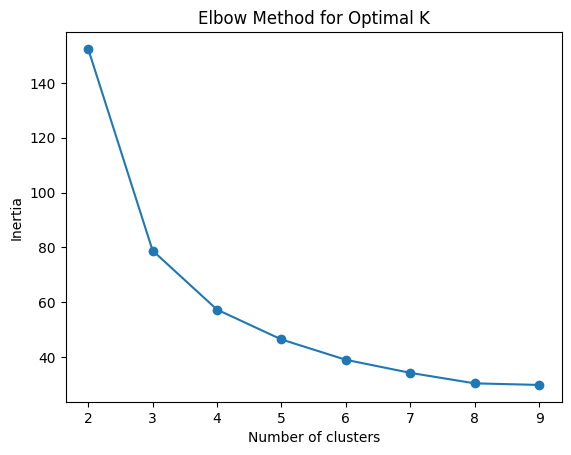

In [12]:
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Load dataset
iris = load_iris()

# Features
X = iris.data

# Elbow Method
inertia = []

K_range = range(2, 10)

for k in K_range:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X)
    inertia.append(model.inertia_)

# Plot
plt.plot(K_range, inertia, marker="o")
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.show()

In [14]:

df.head()

,id,transaction time,transaction type,channel,is 3ds,is token,decision,decline reason code,issuer name,issuer country,...,funding source,acquirer name,acquirer country,acquirer region,jurisdiction,is dispute,is fraud,dispute type,amount,industry segment
0,T89784025544295,2024-02-20T11:02:49.000Z,Chip,CP,No,No,Approved,Approved,BPCE,FRANCE,...,Credit,BOURSORAMA BANQUE,FRANCE,EUROPE,Domestic,0,0,No Dispute,196.975798,Government services
1,T94028747687247,2024-02-18T10:42:19.000Z,Other CNP,CNP,No,No,Approved,Approved,"BANK OF AMERICA, NATIONAL ASSOCIATION",UNITED STATES OF AMERICA,...,Credit,NAVY FEDERAL CREDIT UNION,UNITED STATES OF AMERICA,USA,Domstic,0,0,No Dispute,340.852463,Contracted services
2,T84800389951860,2024-04-30T11:10:17.000Z,ECI-7,CNP,No,No,Approved,Approved,HSBC UK BANK PLC,UNITED KINGDOM,...,Credit,BARCLAYS BANK UK PLC,UNITED KINGDOM,EUROPE,Domestic,0,0,No Dispute,192.134049,Clothing stores
3,T88418230200974,2024-01-08T19:01:35.000Z,Contactless,CP,No,Yes,Approved,Approved,JPMORGAN CHASE BANK N.A,UNITED STATES OF AMERICA,...,Credit,CHAINA MERCHANTS BANK,CHAINA MAINLAND,APAC,Cross Border,0,0,No Dispute,100.581589,Contracted services
4,T19060182064275,2024-05-14T21:03:51.000Z,Chip,CP,No,No,Approved,Approved,BANCO BRADESCO S.A.,BRAZIL,...,Credit,SUTTON BANK,UNITED STATES OF AMERICA,USA,Cross Border,0,0,No Dispute,424.332753,Utility services


In [16]:
print(df.columns.tolist())

['id', 'transaction time', 'transaction type', 'channel', 'is 3ds', 'is token', 'decision', 'decline reason code', 'issuer name', 'issuer country', 'issuer region', 'funding source', 'acquirer name', 'acquirer country', 'acquirer region', 'jurisdiction', 'is dispute', 'is fraud', 'dispute type', 'amount', 'industry segment']


In [19]:
pca = PCA(n_components=2)

reduced = pca.fit_transform(X)

df_small = df.iloc[:len(reduced)].copy()

df_small["x"] = reduced[:, 0]
df_small["y"] = reduced[:, 1]

In [21]:
df = df.rename(columns={"PCA1": "x", "PCA2": "y"})

In [23]:
df.head()

,id,transaction time,transaction type,channel,is 3ds,is token,decision,decline reason code,issuer name,issuer country,...,funding source,acquirer name,acquirer country,acquirer region,jurisdiction,is dispute,is fraud,dispute type,amount,industry segment
0,T89784025544295,2024-02-20T11:02:49.000Z,Chip,CP,No,No,Approved,Approved,BPCE,FRANCE,...,Credit,BOURSORAMA BANQUE,FRANCE,EUROPE,Domestic,0,0,No Dispute,196.975798,Government services
1,T94028747687247,2024-02-18T10:42:19.000Z,Other CNP,CNP,No,No,Approved,Approved,"BANK OF AMERICA, NATIONAL ASSOCIATION",UNITED STATES OF AMERICA,...,Credit,NAVY FEDERAL CREDIT UNION,UNITED STATES OF AMERICA,USA,Domstic,0,0,No Dispute,340.852463,Contracted services
2,T84800389951860,2024-04-30T11:10:17.000Z,ECI-7,CNP,No,No,Approved,Approved,HSBC UK BANK PLC,UNITED KINGDOM,...,Credit,BARCLAYS BANK UK PLC,UNITED KINGDOM,EUROPE,Domestic,0,0,No Dispute,192.134049,Clothing stores
3,T88418230200974,2024-01-08T19:01:35.000Z,Contactless,CP,No,Yes,Approved,Approved,JPMORGAN CHASE BANK N.A,UNITED STATES OF AMERICA,...,Credit,CHAINA MERCHANTS BANK,CHAINA MAINLAND,APAC,Cross Border,0,0,No Dispute,100.581589,Contracted services
4,T19060182064275,2024-05-14T21:03:51.000Z,Chip,CP,No,No,Approved,Approved,BANCO BRADESCO S.A.,BRAZIL,...,Credit,SUTTON BANK,UNITED STATES OF AMERICA,USA,Cross Border,0,0,No Dispute,424.332753,Utility services
